# Imports

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.stats import genextreme
import torch
import torch.nn as nn

# Variables

In [70]:
# define constants
mu = 3              # mean of log
sigma = 1           # std dev of log
C = 9.9e-11         # material const.
m = 2.7             # sensitivity to stress
n = 1.5             # sensitivity to defect size, = nn.Parameter(torch.tensor(1.5))

# define variables
n_defects = 1000    # size of random dataset
defect_size = torch.linspace(start=20,
                             end=600,
                             steps=n_defects)     # surface area of defect, A
stress_amp = torch.linspace(start=50,
                            end=500,
                            steps=n_defects)      # stress amplitude

# Data

In [ ]:
# define fxn to generate the defect sizes based on a lognormal distribution
def generate_defects(n_defects, mu, sigma):
    return np.random.lognormal(mu,           # mean of logarithm 
                               sigma,        # std dev
                               n_defects)    # no. of random samples generated

# generate n_defects random defects
defects = generate_defects(n_defects, mu, sigma)

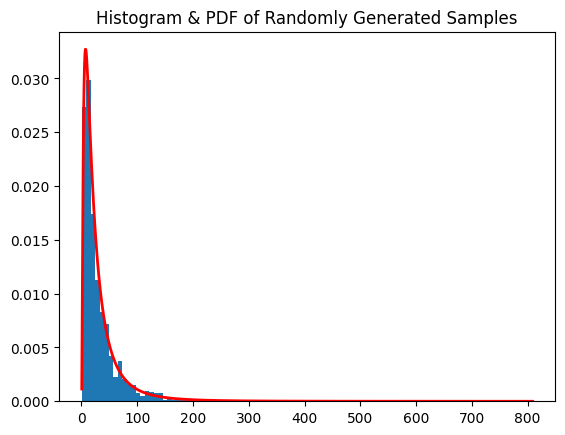

In [ ]:
# show histogram and probability density fxn of randomly generated samples
count, bins, ignored = plt.hist(defects,
                                bins=100,
                                density=True,
                                align='mid')

x = np.linspace(min(bins), max(bins), n_defects)
pdf = (np.exp(-(np.log(x)-mu)**2/(2*sigma**2))
       /(x*sigma*np.sqrt(2*np.pi)))


# axis labels
plt.title('Histogram & PDF of Randomly Generated Samples')

plt.plot(x, pdf, linewidth=2, color='r')
plt.axis('tight')
plt.show()

# Shiozawa

In [73]:
# define fxn to find the fatigue life, N, based on the given parameters
def fatigue_life(stress_amp, defect_size, C, m, n):
    return C / ((stress_amp**m) * (defect_size**n))

## S-N Curve

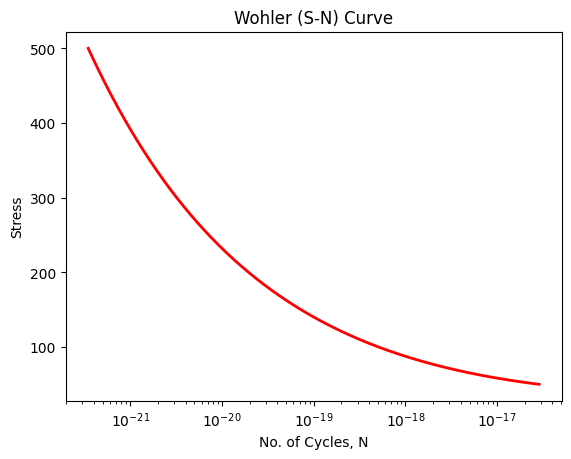

In [124]:
# data
N = fatigue_life(stress_amp, defect_size, C, m, n)    # N, no. of cycles, or fatigue life
S = stress_amp                                        # S, stress

# create an S-N curve
plt.plot(N, S,
         color='red',
         linewidth=2,
         markersize=12,
         )

# axis labels
plt.title('Wohler (S-N) Curve')
plt.xlabel('No. of Cycles, N')
plt.ylabel('Stress')

plt.xscale('log')

plt.show()

# Critical Defects

In [76]:
# define fxn to select the crtical defect
def critical_defect(defects):
    # defect that dominates fatigue failure = max defect
    return np.max(defects)

# calculate the critical defect size
A_crit = critical_defect(defects)
print("The critical (max) defect size is",A_crit)

The critical (max) defect size is 405.0719305084289


## Generalized Extreme Value Distribution (GEV)

- each specimen contains many defects
- fatigue failure governed by the largest critical defect
- so the distribution of maxima tends toward a GEV distribution

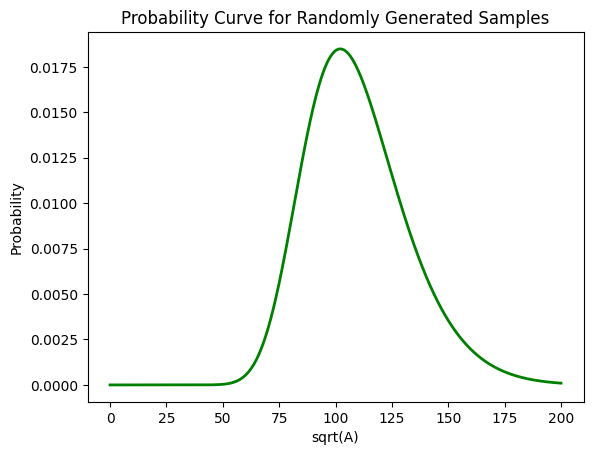

In [91]:
# generate random extreme values
samples = genextreme.rvs(c=0.1,             # shape parameter
                         loc=100,           # center/location
                         scale=20,          # spread
                         size=n_defects)

# calculate pdf
x2 = np.linspace(0, 200, n_defects)
pdf2 = genextreme.pdf(x2, c=0.1, loc=100, scale=20)

# axis labels
plt.title('Probability Curve for Randomly Generated Samples')
plt.xlabel('sqrt(A)')
plt.ylabel('Probability')

plt.plot(x2, pdf2, linewidth=2, color='g')
plt.axis('tight')
plt.show()

# Monte Carlo Loop

**Goal:** Instead of one specimen, simulate n_defects specimens,
- each with random defects
- each with a different fatigue life

In [193]:
lives = []          # list to store fatigue lives
M = []              # list to store Murakami parameter
max_defects = []    # list to store max defects
stress = []         # list to store stress values

for i in range(1000):
    defects = generate_defects(n_defects, mu, sigma)
    A_crit = critical_defect(defects)
    Murakami = np.sqrt(A_crit)     # Murakami parameter for defect size, sqrt(A)
    N = fatigue_life(stress_amp[i], A_crit, C, m, n)
    
    lives.append(N)
    M.append(Murakami)
    max_defects.append(np.max(defects))
    stress.append(stress_amp[i])

## Fatigue Life

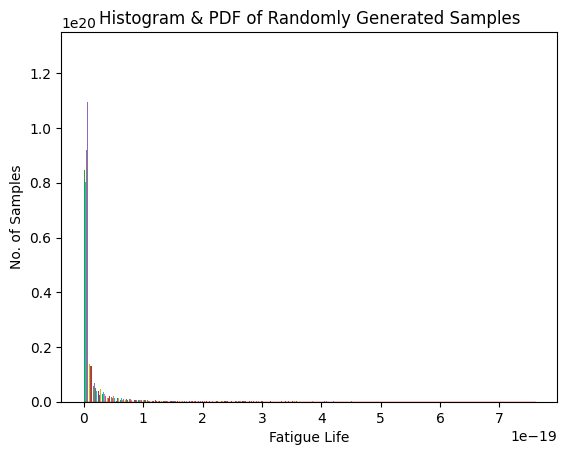

In [93]:
# plot fatigue life histogram
count, bins, ignored = plt.hist(lives,
                                bins=100,
                                density=True,
                                align='mid')

x1 = np.linspace(min(bins), max(bins), n_defects)
pdf1 = (np.exp(-(np.log(x)-mu)**2/(2*sigma**2))
       /(x*sigma*np.sqrt(2*np.pi)))

# axis labels
plt.title('Histogram & PDF of Randomly Generated Samples')
plt.xlabel('Fatigue Life')
plt.ylabel('No. of Samples')

plt.plot(x1, pdf1, linewidth=1, color='r')
plt.axis('tight')
plt.show()

In [94]:
# mean fatigue life
N_avg = np.mean(lives)

# std dev of faigue life
N_sigma = np.std(lives)

print("The average fatigue life is", N_avg)
print("The standard deviation of the fatigue life is", N_sigma)

The average fatigue life is 1.5901321e-20
The standard deviation of the fatigue life is 4.0716234e-20


## GEV, P vs sqrt(A)

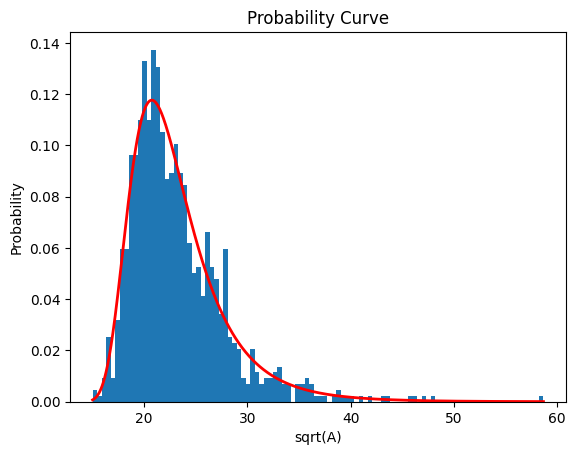

In [107]:
# failure probability, P vs sqrt(defect_size)
c, loc, scale = genextreme.fit(M)

# show histogram and probability density fxn
count, bins, ignored = plt.hist(M,
                                bins=100,
                                density=True,
                                align='mid')

# calculate pdf
x3 = np.linspace(min(M), max(M), n_defects)
pdf3 = genextreme.pdf(x3, c, loc, scale)

# axis labels
plt.title('Probability Curve')
plt.xlabel('sqrt(A)')
plt.ylabel('Probability')

plt.plot(x3, pdf3, linewidth=2, color='r')
plt.axis('tight')
plt.show()

## S-N Curve with CI

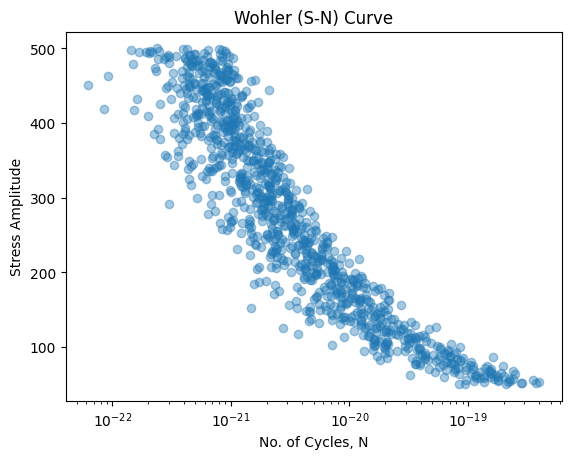

In [194]:
# data
x4 = lives
y4 = stress_amp

# scatter plot of stress vs fatigue life
plt.scatter(x4, y4, alpha=0.4)
plt.xscale('log')

# axis labels
plt.title('Wohler (S-N) Curve')
plt.xlabel('No. of Cycles, N')
plt.ylabel('Stress Amplitude')

plt.xscale('log')

plt.show()

In [195]:
# fix tensor types
lives = np.asarray(lives, dtype=float)
stress = np.asarray(stress, dtype=float)

In [200]:
logN = np.log10(lives)

# create bins for logN
bins = np.linspace(min(logN), max(logN), 20)

# calculate mean and std dev of stress values in each bin
stress_avg = []
stress_std = []
centers = []

for i in range(len(bins) - 1):
    mask = (logN >= bins[i]) & (logN < bins[i+1])
    stresses_in_bin = np.array(stress)[mask]

    if stresses_in_bin.size == 0:
        continue
    
    stress_avg.append(np.mean(np.array(stress, dtype=float)[mask]))
    stress_std.append(np.std(np.array(stress, dtype=float)[mask]))
    centers.append(0.5 * (bins[i] + bins[i+1]))                  #(0.5 * (bins[:-1] + bins[1:]))

stress_avg = np.array(stress_avg)
stress_std = np.array(stress_std)
centers = np.array(centers)

In [201]:
# confidence intervals, assume 96% CI
upper = stress_avg + 1.96 * stress_std
lower = stress_avg - 1.96 * stress_std

upper = np.array(upper)
lower = np.array(lower)

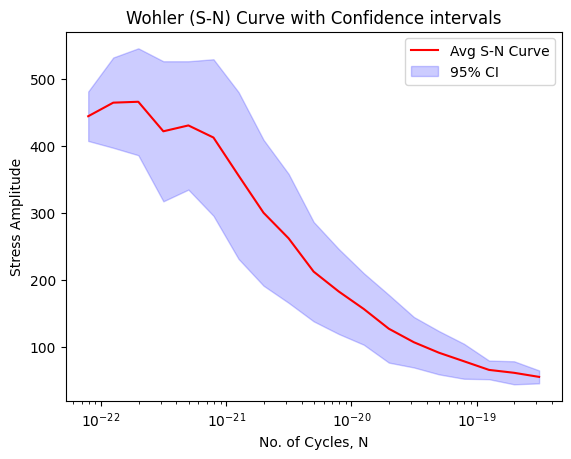

In [204]:
xvals = np.power(10, centers)

plt.plot(xvals, stress_avg, 'red', label='Avg S-N Curve')

plt.fill_between(xvals, lower, upper,
                 color='blue',
                 alpha=0.2,
                 label='95% CI')

plt.xscale('log')

# axis labels
plt.title('Wohler (S-N) Curve with Confidence intervals')
plt.xlabel('No. of Cycles, N')
plt.ylabel('Stress Amplitude')

plt.xscale('log')
plt.legend()
plt.show()

In [97]:
# reliability curves